<a href="https://colab.research.google.com/github/BadhonPain/Machine_Learning/blob/ML/Clustering_and_Dimensionality_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T**ask 1 – K-Means & Elbow Method**

In [27]:
from sklearn.datasets import load_iris
import numpy as np
iris = load_iris()

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
X = iris.data
df = pd.DataFrame(X, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

# Train model
kmeans.fit(X)
# Cluster labels
clusters = kmeans.labels_
# Add cluster labels to DataFrame
df["Cluster"] = clusters

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


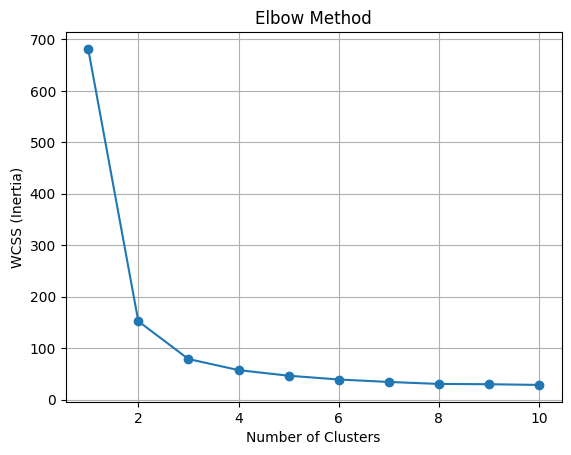

In [9]:
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS (Inertia)")
plt.grid(True)
plt.show()

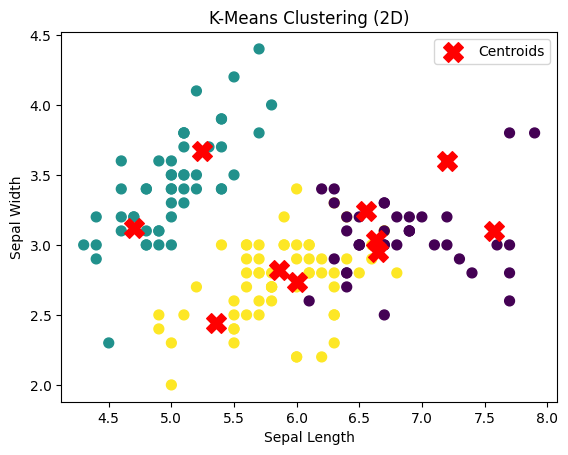

In [14]:


plt.scatter(
    X[:,0],
    X[:,1],
    c=clusters,
    cmap="viridis",
    s=50
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color="red",
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Means Clustering (2D)")
plt.legend()
plt.show()

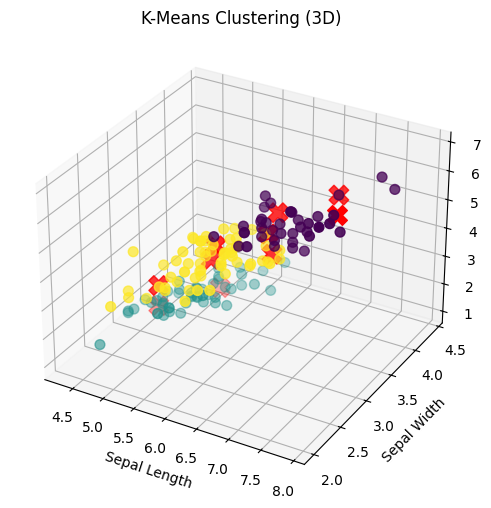

In [18]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X[:,0],
    X[:,1],
    X[:,2],
    c=clusters,
    cmap="viridis",
    s=50
)

ax.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    kmeans.cluster_centers_[:,2],
    color="red",
    marker="X",
    s=200
)

ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_zlabel("Petal Length")

plt.title("K-Means Clustering (3D)")
plt.show()

In [19]:
df["Species"] = iris.target

pd.crosstab(df["Cluster"], df["Species"])

Species,0,1,2
Cluster,,,
0,0,3,36
1,50,0,0
2,0,47,14


# **Task 2 – PCA & Visualization**


In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [26]:
iris = load_iris()
X = iris.data
y = iris.target

scaler = StandardScaler() # Standerdizing
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)  # Applying PCA
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Species"] = y

df_pca.head()

,PC1,PC2,Species
0,-2.684126,0.319397,0
1,-2.714142,-0.177001,0
2,-2.888991,-0.144949,0
3,-2.745343,-0.318299,0
4,-2.728717,0.326755,0


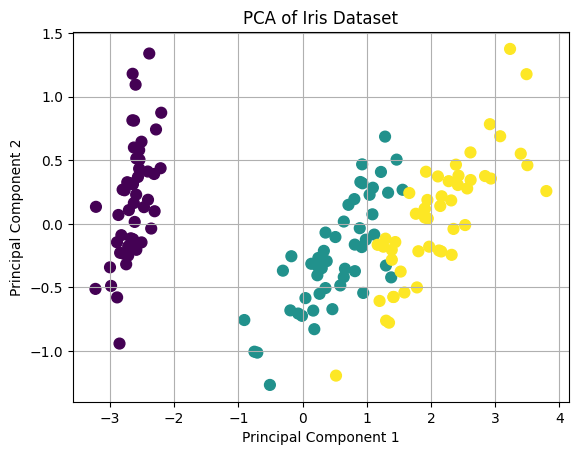

In [31]:

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap="viridis",
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Iris Dataset")

plt.grid(True)
plt.show()

In [28]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("\nExplained variance ratio:")
print([f"{x:.2f}" for x in explained_variance])

print("\nCumulative explained variance:")
print([f"{x:.2f}" for x in cumulative_variance])



Explained variance ratio:
['0.92', '0.05']

Cumulative explained variance:
['0.92', '0.98']


# **Task 3 – Hierarchical Clustering & Dendrogram**

In [32]:
from sklearn.cluster import AgglomerativeClustering

In [33]:
iris = load_iris()
X = iris.data
y = iris.target

hc = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

hierarchical_clusters = hc.fit_predict(X)

df = pd.DataFrame(X, columns=iris.feature_names)
df["Hierarchical Cluster"] = hierarchical_clusters

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Hierarchical Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


In [35]:
from scipy.cluster.hierarchy import dendrogram, linkage


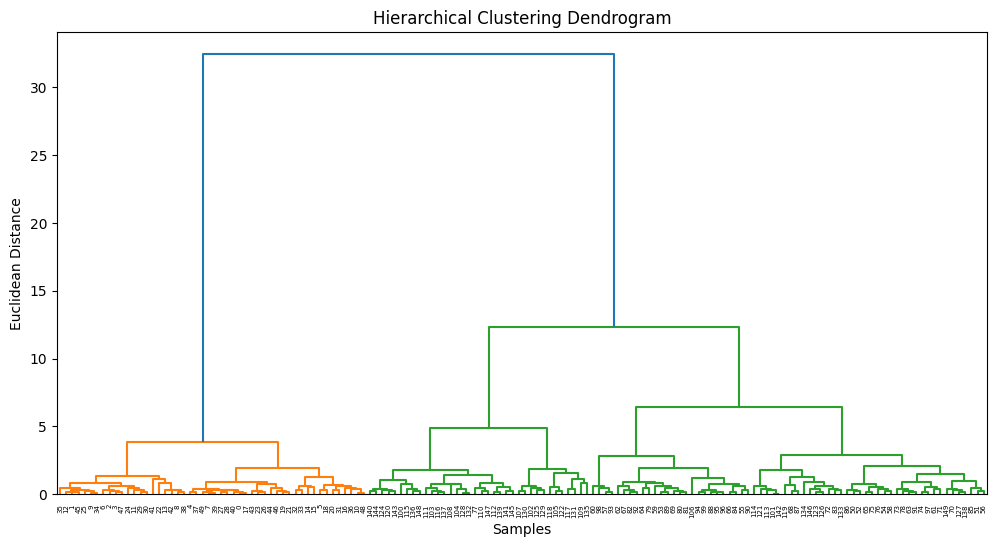

In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Z = linkage(X, method='ward')

plt.figure(figsize=(12,6))

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Euclidean Distance")

plt.show()

In [43]:
kmeans = KMeans(  # applying K-means
    n_clusters=3,
    random_state=42
)

kmeans_clusters = kmeans.fit_predict(X)

comparison = pd.DataFrame({  # appyling clustering
    "Actual Species": y,
    "Hierarchical": hierarchical_clusters,
    "KMeans": kmeans_clusters
})
print("Hierarchical Clustering")  # print compraison
pd.crosstab(hierarchical_clusters, y)

Hierarchical Clustering


col_0,0,1,2
row_0,,,
0,0,49,15
1,50,0,0
2,0,1,35


# **Task 4 – DBSCAN Clustering**

In [44]:
from sklearn.cluster import DBSCAN


In [46]:
iris = load_iris()
X = iris.data
y = iris.target

# Applying DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_clusters = dbscan.fit_predict(X)

df = pd.DataFrame(X, columns=iris.feature_names)
df["DBSCAN Cluster"] = dbscan_clusters

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),DBSCAN Cluster
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [48]:

params = [
    (0.3, 5),
    (0.5, 5),
    (0.7, 5),
    (0.9, 5),
    (0.5, 3),
    (0.5, 10)
]

for eps, min_samples in params:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"eps={eps}, min_samples={min_samples}")
    print(f"Clusters: {n_clusters}")
    print(f"Noise Points: {n_noise}")
    print("-"*40)

eps=0.3, min_samples=5
Clusters: 3
Noise Points: 96
----------------------------------------
eps=0.5, min_samples=5
Clusters: 2
Noise Points: 17
----------------------------------------
eps=0.7, min_samples=5
Clusters: 2
Noise Points: 3
----------------------------------------
eps=0.9, min_samples=5
Clusters: 2
Noise Points: 0
----------------------------------------
eps=0.5, min_samples=3
Clusters: 4
Noise Points: 10
----------------------------------------
eps=0.5, min_samples=10
Clusters: 2
Noise Points: 30
----------------------------------------


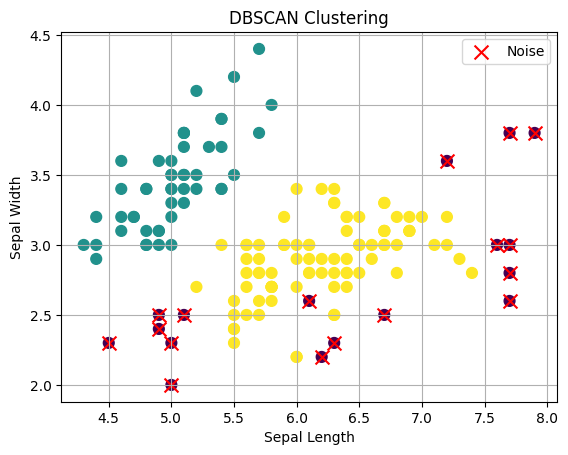

In [52]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dblabels = dbscan.fit_predict(X)

# Plot clusters
plt.scatter(
    X[:,0],
    X[:,1],
    c=dblabels,
    cmap='viridis',
    s=60
)

# Highlight noise points
noise = dblabels == -1

plt.scatter(
    X[noise,0],
    X[noise,1],
    color='red',
    marker='x',
    s=100,
    label='Noise'
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("DBSCAN Clustering")

plt.legend()
plt.grid(True)
plt.show()

In [54]:

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_clusters = kmeans.fit_predict(X)

comparison = pd.DataFrame({
    "Actual Species": y,
    "DBSCAN": labels,
    "KMeans": kmeans_clusters
})

comparison.head()

,Actual Species,DBSCAN,KMeans
0,0,0,1
1,0,0,1
2,0,0,1
3,0,0,1
4,0,0,1


In [56]:
print("DBSCAN")
pd.crosstab(labels, y)

DBSCAN


col_0,0,1,2
row_0,,,
-1,1,6,10
0,49,0,0
1,0,44,40


In [57]:
print("K-Means")
pd.crosstab(kmeans_clusters, y)

K-Means


col_0,0,1,2
row_0,,,
0,0,3,36
1,50,0,0
2,0,47,14
